In [2]:
#Checking

In [3]:
%pip install opencv-python matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.3/48.3 MB 25.6 MB/s  0:00:01a 0:00:010:00:01:01
Note: you may need to restart the kernel to use updated packages.


Using Data Directory: /Users/ava/OilSpill_SIH/data

Train set: 6455 images, 6455 masks
Val set:   1615 images, 1615 masks

Image: shape=(256, 256), dtype=uint8, range=[0, 255]
Mask:  shape=(256, 256), dtype=uint8, unique_values=[  0 255]


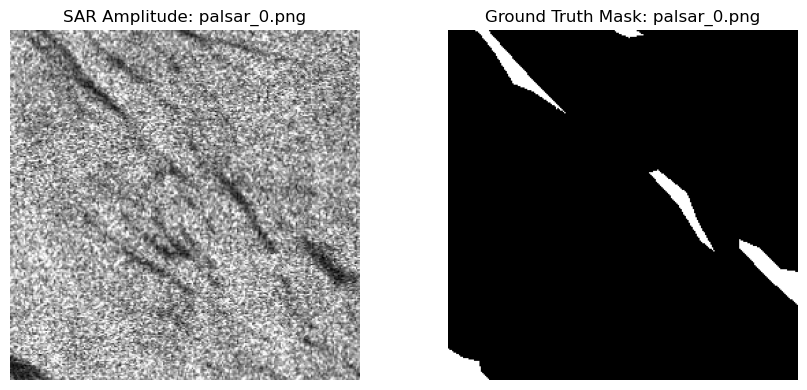

In [7]:
import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Set the base directory pointing one level up to the repo root
BASE_DIR = Path("..").resolve() / "data"

# If that still isn't found (e.g. if the notebook kernel started at root), fall back to local "Data"
if not BASE_DIR.exists():
    BASE_DIR = Path("Data").resolve()

print(f"Using Data Directory: {BASE_DIR}")
assert BASE_DIR.exists(), f"Directory not found at {BASE_DIR}"

# Collect file paths
train_images = sorted(glob.glob(str(BASE_DIR / "images" / "images" / "train" / "*.*")))
train_masks  = sorted(glob.glob(str(BASE_DIR / "masks"  / "masks"  / "train" / "*.*")))
val_images   = sorted(glob.glob(str(BASE_DIR / "images" / "images" / "val"   / "*.*")))
val_masks    = sorted(glob.glob(str(BASE_DIR / "masks"  / "masks"  / "val"   / "*.*")))

print(f"\nTrain set: {len(train_images)} images, {len(train_masks)} masks")
print(f"Val set:   {len(val_images)} images, {len(val_masks)} masks")

# Assertions to ensure data loaded properly
assert len(train_images) > 0, "Still 0 images found. Check folder casing (e.g. 'data' vs 'Data')."
assert len(train_images) == len(train_masks), "Image and mask counts do not match!"

# Load and inspect the first sample pair
img = cv2.imread(train_images[0], cv2.IMREAD_GRAYSCALE)
mask = cv2.imread(train_masks[0], cv2.IMREAD_GRAYSCALE)

print(f"\nImage: shape={img.shape}, dtype={img.dtype}, range=[{img.min()}, {img.max()}]")
print(f"Mask:  shape={mask.shape}, dtype={mask.dtype}, unique_values={np.unique(mask)}")

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(img, cmap="gray")
axes[0].set_title(f"SAR Amplitude: {Path(train_images[0]).name}")
axes[0].axis("off")

axes[1].imshow(mask, cmap="gray")
axes[1].set_title(f"Ground Truth Mask: {Path(train_masks[0]).name}")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [8]:
import numpy as np

# Sample 200 masks to quickly estimate global class imbalance
sample_indices = np.random.choice(len(train_masks), size=min(200, len(train_masks)), replace=False)
total_pixels = 0
oil_pixels = 0

for idx in sample_indices:
    m = cv2.imread(train_masks[idx], cv2.IMREAD_GRAYSCALE)
    oil_pixels += np.sum(m > 127)
    total_pixels += m.size

spill_ratio = (oil_pixels / total_pixels) * 100
print(f"Oil spill pixel percentage: {spill_ratio:.2f}%")
print(f"Clean water / background percentage: {100 - spill_ratio:.2f}%")

Oil spill pixel percentage: 25.43%
Clean water / background percentage: 74.57%
